# Figure 2


## Load Model

In [ ]:
import os
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from models.dynnet import DynNet_Hard
from utils.solver import euler_solver_sde
from utils.load_data import load_misa_data


# Load additional data for another simulation
data,refgrn,yi,yf = load_misa_data('data\MISA_TS\MISA_TS.npy')
# Initialize parameters for the second model
model = DynNet_Hard(0.1, 0.2, grn)
model.load_state_dict(torch.load('models\checkpoints\MISA_MS\MISA_TS.pth'))


<All keys matched successfully>

## Generate Estimated data

In [30]:
with torch.no_grad():
    trajectory = euler_solver_sde(model, y0)

# Extract and plot final trajectory
traj = trajectory[-1]
y_f = traj.detach().numpy()

## Figure Show

### Figure 2C

In [40]:
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(yf)
y_data_mean = gmm.means_
y_data_cov = gmm.covariances_
gmm.fit(y_f)
y_est_mean = gmm.means_
y_est_cov = gmm.covariances_

c:\Users\cetus\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\cetus\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


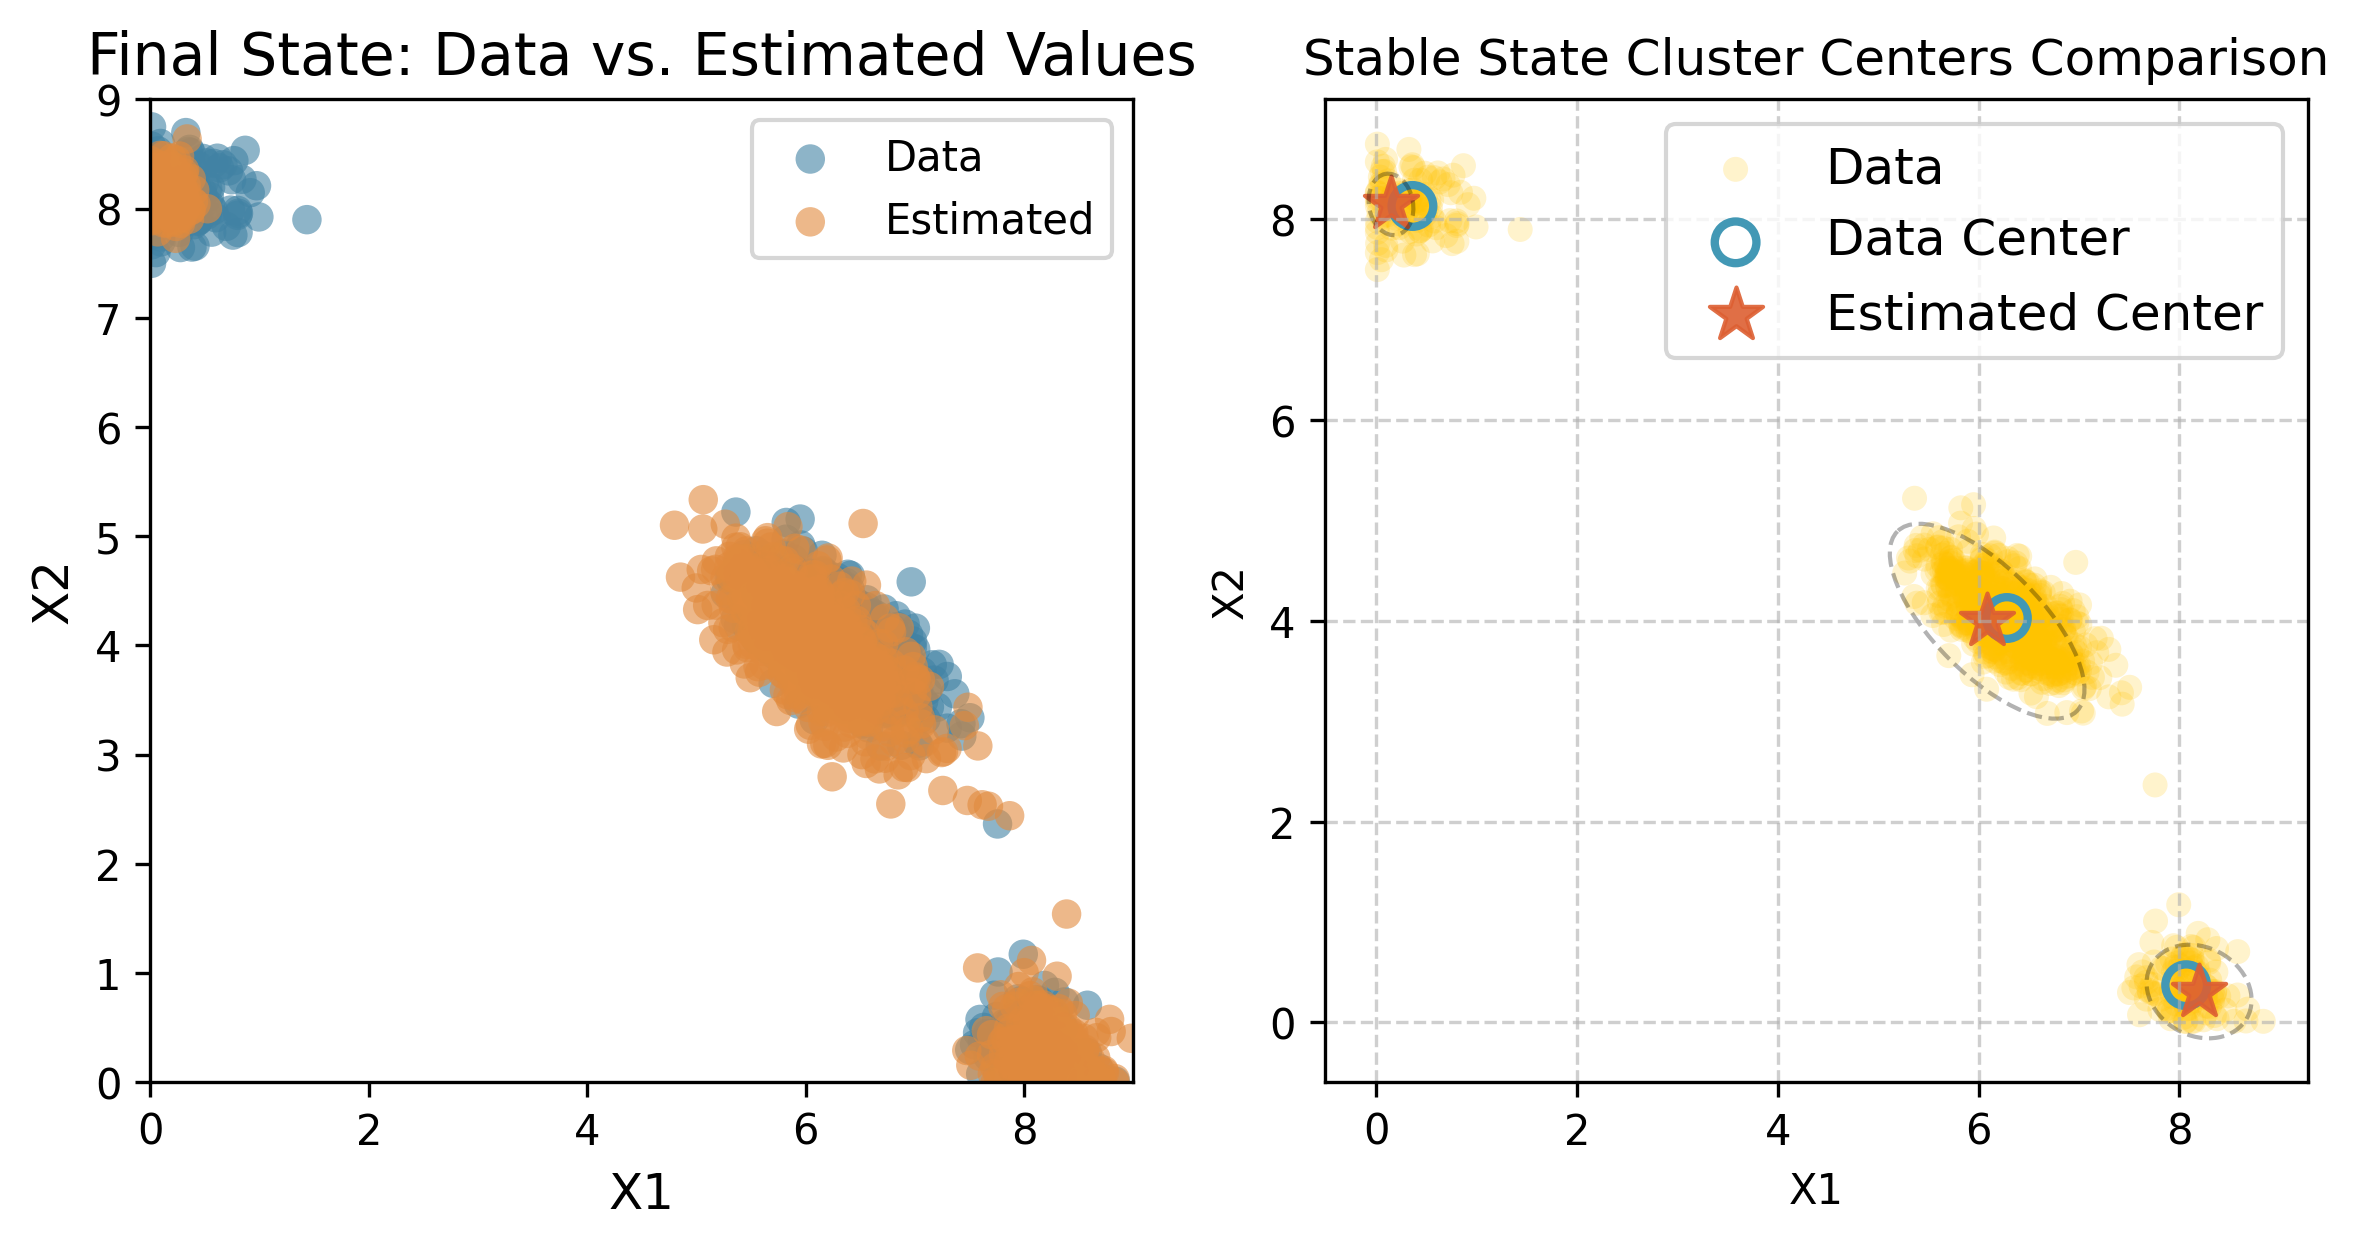

In [51]:
# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# Scatter comparison plot with enhanced aesthetics for the first subplot
axs[0].scatter(yf[:, 0], yf[:, 1], color='#4182a4', label='Data', alpha=0.6, edgecolor='none', s=50, linewidth=0.5)
axs[0].scatter(y_f[:, 0], y_f[:, 1], color='#e18a3d', label='Estimated', alpha=0.6, edgecolor='none', s=50, linewidth=0.5)
# Set limits labels for the first subplot
axs[0].set_xlim(0, 9)
axs[0].set_ylim(0, 9)
axs[0].set_xlabel('X1', fontsize=12)
axs[0].set_ylabel('X2', fontsize=12)
axs[0].set_title('Final State: Data vs. Estimated Values', fontsize=14)

# Customize grid and aspect ratio for the first subplot
axs[0].grid(False)
axs[0].set_aspect('equal', adjustable='box')
axs[0].legend(fontsize=10, loc='best', frameon=True)

# Scatter plot for the second subplot
axs[1].scatter(yf[:, 0], yf[:, 1], alpha=0.2, edgecolors='none', facecolor='#ffc300', label='Data')
axs[1].scatter(y_data_mean[:, 0], y_data_mean[:, 1], facecolors='none', edgecolors='#4298b5', alpha=1, 
               label='Data Center', marker='o', s=100, linewidths=2)
axs[1].scatter(y_est_mean[:, 0], y_est_mean[:, 1], color='#dd5f32', alpha=0.9, 
               label='Estimated Center', marker='*', s=180)
import numpy as np

def plot_cov_ellipse(cov, pos, ax, n_std=2, **kwargs):
    """Plot an ellipse representing the covariance matrix."""
    # Calculate the eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Calculate the angle of the ellipse
    angle = np.arctan2(*eigenvectors[:, 0][::-1])
    # Calculate the width and height of the ellipse
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    # Create the ellipse
    from matplotlib.patches import Ellipse
    ellipse = Ellipse(xy=pos, width=width, height=height, angle=np.degrees(angle), **kwargs)
    ax.add_patch(ellipse)

# Plot the covariance ellipses for estimated centers
for mean, cov in zip(y_est_mean, y_est_cov):
    plot_cov_ellipse(cov, mean[:2], axs[1], edgecolor = 'k',facecolor = 'none' ,alpha=0.3, linestyle='--')

# Set labels and title for the second subplot
axs[1].legend(fontsize=12, loc='best')
axs[1].set_xlabel('X1')
axs[1].set_ylabel('X2')
axs[1].set_title('Stable State Cluster Centers Comparison')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].set_aspect('equal', adjustable='box')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

### Figure 2D Marginal Distribution

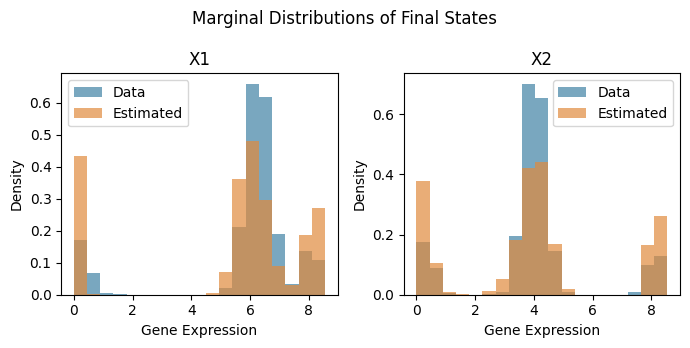

In [60]:
subtitle = ['X1', 'X2']
cols = math.ceil(math.sqrt(n)) 
rows = math.ceil(n / cols) 
fig, axs = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5)) 

for i in range(2):
    ax = axs.flatten()[i]
    ax.hist(yf[:, i], np.arange(0, 9, 0.45), alpha=0.7, color='#4182a4', label='Data', density=True)
    ax.hist(y_f[:,  i], np.arange(0, 9, 0.45), alpha=0.7, color='#e18a3d', label='Estimated', density=True)
    
    ax.set_title(subtitle[i])
    ax.set_xlabel('Gene Expression')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Marginal Distributions of Final States', fontsize=12)
plt.tight_layout()
plt.show()

c:\Users\cetus\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\cetus\miniconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


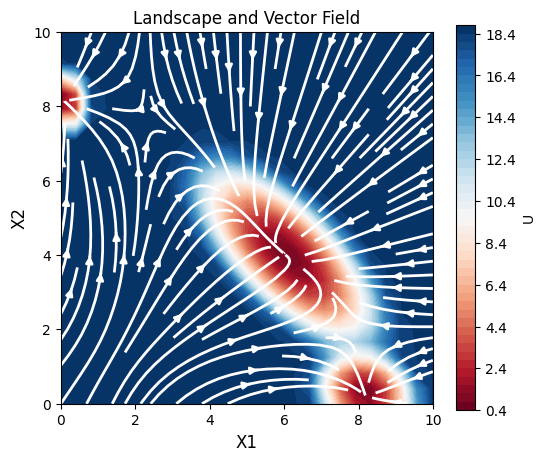

In [65]:
# Fit Gaussian Mixture Model to observed data
observed_data = yf
gmm_model = GaussianMixture(n_components=3, random_state=0).fit(observed_data)
observed_data_mean, observed_data_covariance = gmm_model.means_, gmm_model.covariances_

# Fit Gaussian Mixture Model to estimated data
estimated_data = y_f
gmm_model.fit(estimated_data)
estimated_data_mean, estimated_data_covariance = gmm_model.means_, gmm_model.covariances_

# Prepare grid for vector field and landscape plot
x_limits, y_limits = (0, 10), (0, 10)
grid_resolution = 25
X_grid, Y_grid = np.meshgrid(
    np.linspace(*x_limits, grid_resolution),
    np.linspace(*y_limits, grid_resolution)
)
grid_coordinates = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

# Convert grid coordinates to tensor
grid_tensor = torch.tensor(grid_coordinates, dtype=torch.float32)

# Calculate force field without gradient tracking
with torch.no_grad():
    force_field = model.force(grid_tensor).numpy()

# Reshape force field components
force_x, force_y = force_field[:, 0].reshape(X_grid.shape), force_field[:, 1].reshape(X_grid.shape)

# Calculate landscape
landscape = -np.log(np.exp(gmm_model.score_samples(grid_coordinates)).reshape(X_grid.shape) + 1e-8)

# Plot landscape and vector field
figure, axis = plt.subplots(figsize=(6, 5))
contour_plot = axis.contourf(X_grid, Y_grid, landscape, levels=50, cmap='RdBu')
plt.colorbar(contour_plot, ax=axis, label='U')
axis.streamplot(X_grid, Y_grid, force_x, force_y, color='white', linewidth=2, density=1)

# Set plot properties
axis.set_aspect('equal', adjustable='box')
axis.set_xlim(x_limits)
axis.set_ylim(y_limits)
axis.set_xlabel('X1', fontsize=12)
axis.set_ylabel('X2', fontsize=12)
axis.set_title('Landscape and Vector Field', fontsize=12)
plt.show()


### Figure 2F Decision Boundary

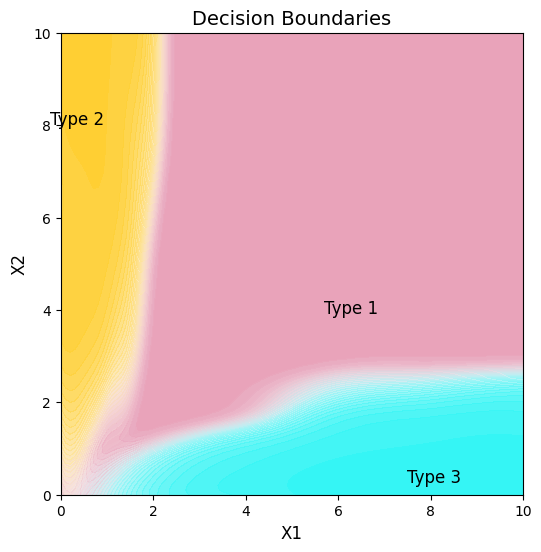

In [59]:
# Probability contours plot
Prob, X, Y, center = calculate_kde_probabilities(yf, y0, x_range=(0, 10), y_range=(0, 10), bandwidth=0.5)
cmaplist = [
    create_alpha_cmap(LinearSegmentedColormap.from_list('custom_gradient', [(1, 1, 1), colors[0]]), alpha_levels),
    create_alpha_cmap(LinearSegmentedColormap.from_list('custom_gradient', [(1, 1, 1), colors[2]]), alpha_levels),
    create_alpha_cmap(LinearSegmentedColormap.from_list('custom_gradient', [(1, 1, 1), colors[4]]), alpha_levels)
]

fig, ax = plt.subplots(figsize=(6, 6))
for i in range(len(Prob)):
    contour = ax.contourf(X, Y, Prob[i], levels=np.linspace(0, 1, 30), cmap=cmaplist[i])

# Set plot properties for decision boundaries
ax.set_aspect('equal', adjustable='box')
ax.set_xlim((0, 10))
ax.set_ylim((0, 10))
ax.set_title('Decision Boundaries', fontsize=14)
ax.set_xlabel('X1', fontsize=12)
ax.set_ylabel('X2', fontsize=12)

# Annotate centers
for idx, (x, y) in enumerate(center):
    ax.text(x, y, f'Type {idx + 1}', fontsize=12, ha='center', va='center', color='black')

plt.show()
